In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from skimage.measure import label, regionprops

import astropy.units as u
from astropy.coordinates import SkyCoord

import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE, HMI_LOS_IMAGE

In [2]:
# 1. Cargamos el mapa de la corona (AIA 171 Å)
aia = sunpy.map.Map(AIA_171_IMAGE)

# 2. Recortamos una "caja" específica en el mapa AIA usando coordenadas físicas (arcsec)
aia = aia.submap(
    bottom_left=SkyCoord(-250, 200, unit=u.arcsec, frame=aia.coordinate_frame),
    width=500 * u.arcsec,
    height=400 * u.arcsec,
)

# 3. Cargamos el mapa magnético de la superficie (HMI)
hmi = sunpy.map.Map(HMI_LOS_IMAGE)

# 4. Recortamos HMI usando exactamente las mismas coordenadas del recorte de AIA
hmi = hmi.submap(aia.bottom_left_coord, top_right=aia.top_right_coord)

# 5. Reproyectamos AIA a las coordenadas de HMI
aia = aia.reproject_to(hmi.wcs)
aia.nickname = 'AIA'

In [3]:
# 1. Creamos una matriz booleana (True/False). True para los píxeles más oscuros que 200 unidades
segmented = aia.data < 200

# 2. La librería skimage agrupa los píxeles 'True' que están juntos y les asigna un número de "isla"
labeled = label(segmented)

# 3. Extraemos las propiedades de cada isla (área, centro, etc.) cruzándolas con los datos de HMI
regions = regionprops(labeled, hmi.data)

# 4. Ordenamos las islas de mayor a menor tamaño (por su área)
regions = sorted(regions, key=lambda r: r.area, reverse=True)

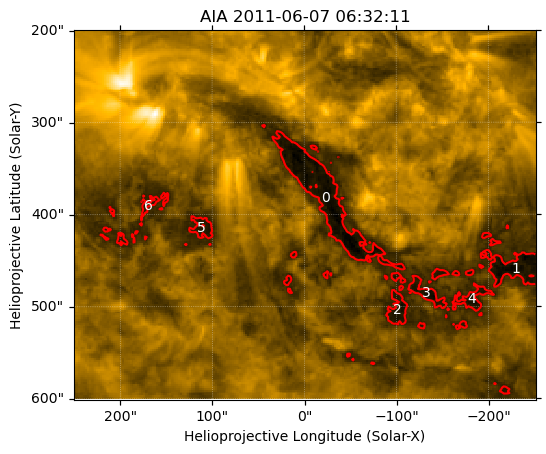

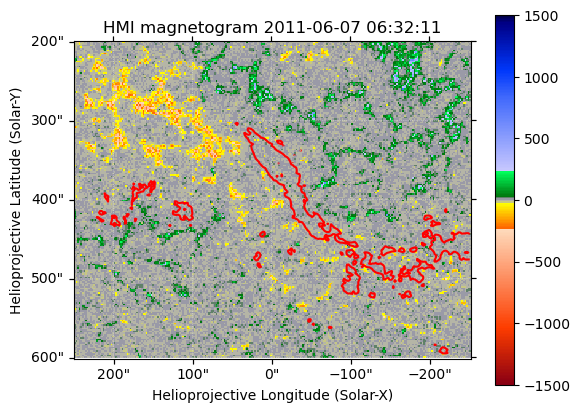

In [4]:
# --- GRÁFICO 1: Mapa de AIA con contornos ---
fig = plt.figure()
ax = fig.add_subplot(projection=aia) # Usamos la proyección celeste del mapa
aia.plot(axes=ax)
aia.draw_contours(axes=ax, levels=200, colors="r") # Dibuja una línea roja en el límite de brillo de 200

# Ponemos un número blanco en el centro de las 7 islas más grandes encontradas
for i in range(7):
    plt.text(*np.flip(regions[i].centroid), str(i), color="w", ha="center", va="center")

# --- GRÁFICO 2: Mapa de HMI con los mismos contornos ---
fig = plt.figure()
ax = fig.add_subplot(projection=hmi)
im = hmi.plot(axes=ax, cmap="hmimag", norm=Normalize(-1500, 1500)) # Gris=Neutro, Blanco/Negro=Campos magnéticos intensos
aia.draw_contours(axes=ax, levels=200, colors="r") # Superpone las líneas rojas de AIA sobre el mapa magnético
fig.colorbar(im)

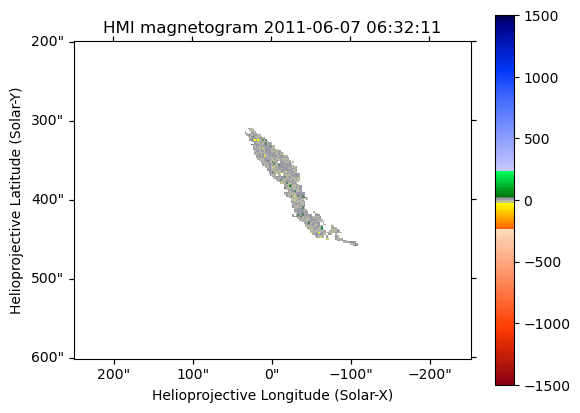

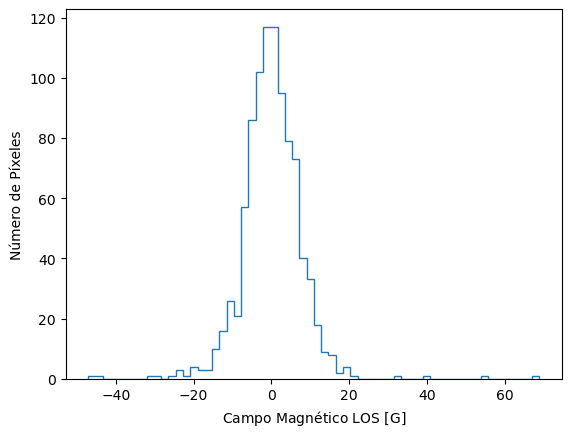

In [5]:
# 1. Obtenemos la caja delimitadora (coordenadas de los extremos) de la isla más grande (la 0)
bbox = regions[0].bbox

# 2. Creamos una matriz llena de "True" (una máscara que al principio tapa todo)
mask = np.ones_like(hmi.data, dtype=bool)

# 3. En la zona de la caja delimitadora, "destapamos" (False) únicamente los píxeles que forman la isla
mask[bbox[0]: bbox[2], bbox[1]: bbox[3]] = ~regions[0].image

# 4. Creamos un nuevo mapa de SunPy que combina los datos de HMI con nuestra máscara protectora
hmi_masked = sunpy.map.Map((hmi.data, hmi.meta), mask=mask)

# --- GRÁFICO 3: Visualizar solo la región aislada ---
fig = plt.figure()
ax = fig.add_subplot(projection=hmi_masked)
im = hmi_masked.plot(axes=ax, cmap="hmimag", norm=Normalize(-1500, 1500))
fig.colorbar(im)

# --- GRÁFICO 4: Histograma estadístico ---
fig = plt.figure()
ax = fig.add_subplot()
# Graficamos la distribución de los valores magnéticos SOLO de los píxeles libres de la máscara
ax.hist(hmi_masked.data[~hmi_masked.mask], bins='auto', histtype='step')
ax.set_ylabel('Número de Píxeles')
ax.set_xlabel(f'Campo Magnético LOS [{hmi.unit:latex_inline}]')

plt.show()